In [1]:
import numpy as np
import matplotlib.pyplot as plt

(0.1, 17.0)

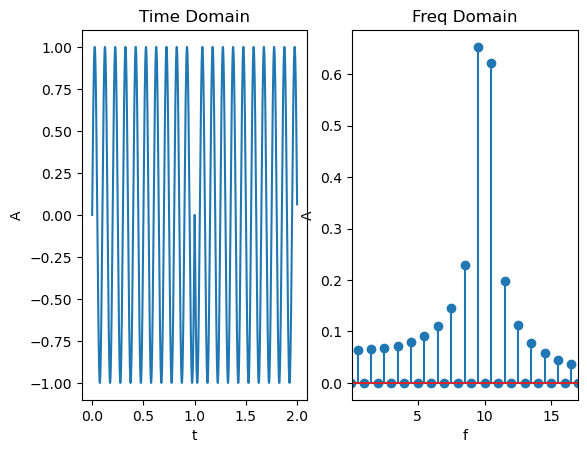

In [ ]:
fs = 1000
N = 2000

t = np.arange(N) / fs
f = 10
sig = np.concatenate([np.sin(2 * np.pi * f * t[:N//2]), np.sin(2 * np.pi * f * t[N//2:] + np.pi)])

fCoeffs = np.fft.rfft(sig) * 2/N
fCoeffs[0] /= 2
hz = np.fft.rfftfreq(N, 1/fs)

plt.subplot(121)
plt.plot(t, sig)
plt.ylabel("A")
plt.xlabel("t")
plt.title("Time Domain")

plt.subplot(122)
plt.stem(hz, np.abs(fCoeffs))
plt.ylabel("A")
plt.xlabel("f")
plt.title("Freq Domain")
plt.xlim(0.1, 17)

# Welch's method

(0.1, 17.0)

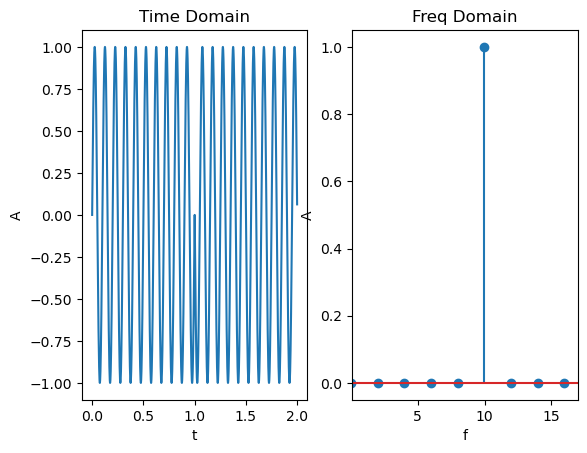

In [34]:
fs = 1000
N = 2000

t = np.arange(N) / fs
f = 10
sig = np.concatenate([np.sin(2 * np.pi * f * t[: N // 2]), np.sin(2 * np.pi * f * t[N // 2 :] + np.pi)])

win_len = 500
stride = 500
nsteps = (N - win_len) // stride + 1
fCoeffs = np.zeros(win_len // 2 + 1, dtype="complex")

for i in range(nsteps):
    fCoeff = np.fft.rfft(sig[i * win_len : (i + 1) * win_len]) * 2 / N
    fCoeff[0] /= 2
    fCoeffs += np.abs(fCoeff)

hz = np.fft.rfftfreq(win_len + 1, 1 / fs)

plt.subplot(121)
plt.plot(t, sig)
plt.ylabel("A")
plt.xlabel("t")
plt.title("Time Domain")

plt.subplot(122)
plt.stem(hz, np.abs(fCoeffs))
plt.ylabel("A")
plt.xlabel("f")
plt.title("Freq Domain")
plt.xlim(0.1, 17)